This project analyzes NBA team 3 point efficiency for the 2025-26 NBA Regular Season. I'm looking at which teams we're the most efficient from three, how volume factors into overall three point value, and how the New York Knicks compare to the rest of the league.

First I pulled 3PT shooting data from NBA API.

In [1]:
from nba_api.stats.endpoints import leaguedashteamstats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

headers = {
    'Host': 'stats.nba.com',
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept': 'application/json',
    'Accept-Language': 'en-US,en;q=0.5',
    'Referer': 'https://www.nba.com/',
    'Connection': 'keep-alive',
}

league_stats = leaguedashteamstats.LeagueDashTeamStats(
    season='2025-26',
    headers=headers,
    timeout=30
)

df_league = league_stats.get_data_frames()[0]

I then filtered for the categories I wanted.

In [2]:
df_three = df_league[['TEAM_NAME', 'FG3M', 'FG3A', 'FG3_PCT']].copy()

In addition, I calculated Three Point Value by multiplying three point percentage by three pointers attempted and the point value of a three to see what value teams were actually getting from their three point shooting.

In [3]:
df_three['THREE_POINT_VALUE'] = df_three['FG3A'] * df_three['FG3_PCT'] * 3
df_value_sorted = df_three.sort_values('THREE_POINT_VALUE', ascending=False).reset_index(drop=True)

I showed all these values in a table sorted by 3pt percentage to analyze efficiency.

In [4]:
df_sorted = df_three.sort_values('FG3_PCT', ascending=False).reset_index(drop=True)
print(df_sorted)

                 TEAM_NAME  FG3M  FG3A  FG3_PCT  THREE_POINT_VALUE
0           Denver Nuggets  1161  2934    0.396           3485.592
1          Milwaukee Bucks  1240  3205    0.387           3721.005
2        Charlotte Hornets  1343  3549    0.378           4024.566
3          New York Knicks  1168  3133    0.373           3505.827
4            Atlanta Hawks  1201  3237    0.371           3602.781
5   Minnesota Timberwolves  1128  3049    0.370           3384.390
6              LA Clippers  1019  2772    0.368           3060.288
7           Boston Celtics  1268  3456    0.367           3805.056
8    Oklahoma City Thunder  1135  3111    0.365           3406.545
9          Houston Rockets   940  2580    0.364           2817.360
10            Phoenix Suns  1210  3348    0.361           3625.884
11              Miami Heat  1123  3107    0.361           3364.881
12     Cleveland Cavaliers  1173  3261    0.360           3521.880
13      Washington Wizards  1070  2983    0.359           3212

I then pull the Knicks numbers specifically.

In [5]:
knicks_rank = df_sorted.reset_index(drop=True)
knicks_row = knicks_rank[knicks_rank['TEAM_NAME'] == 'New York Knicks']
print(knicks_row)

         TEAM_NAME  FG3M  FG3A  FG3_PCT  THREE_POINT_VALUE
3  New York Knicks  1168  3133    0.373           3505.827


Then I plotted all the teams in order of three point percentage and highlighted the Knicks in blue.

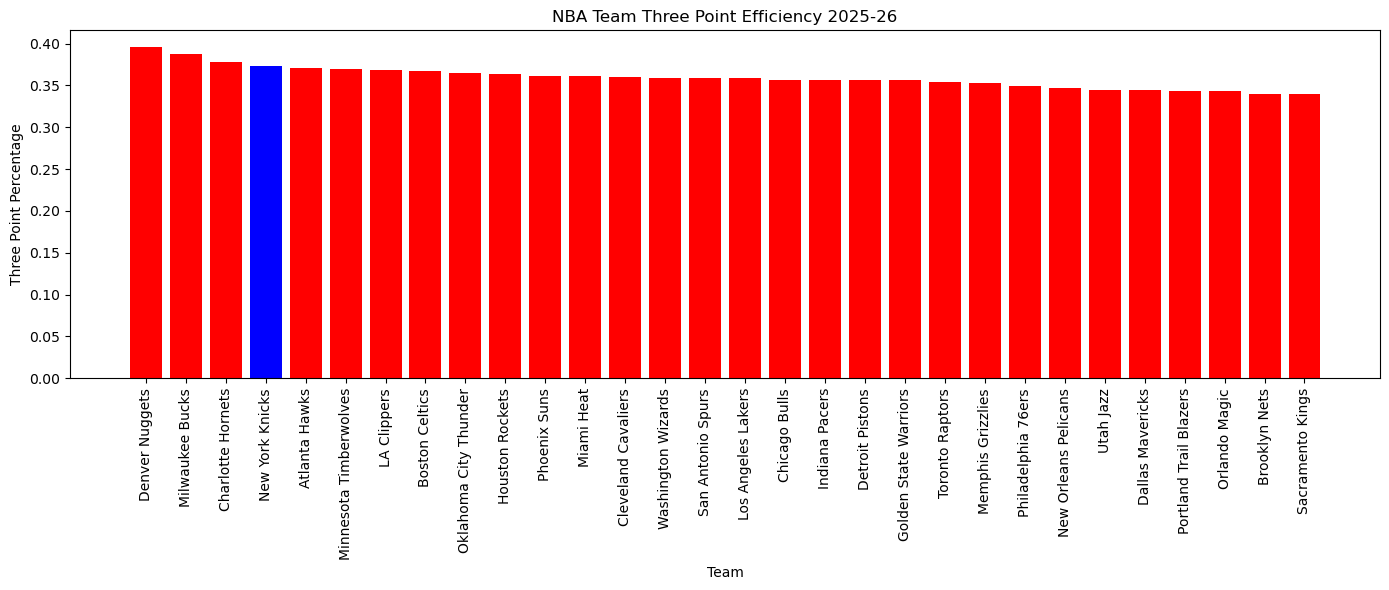

In [6]:
colors = ['blue' if team == 'New York Knicks' else 'red' for team in df_sorted['TEAM_NAME']]

plt.figure(figsize=(14, 6))
plt.bar(df_sorted['TEAM_NAME'], df_sorted['FG3_PCT'], color=colors)
plt.xticks(rotation=90)
plt.xlabel('Team')
plt.ylabel('Three Point Percentage')
plt.title('NBA Team Three Point Efficiency 2025-26')
plt.tight_layout()
plt.show()

We can see here the Knicks are 4th in the NBA in terms of 3pt percentage, shooting 37.3% from three, meaning they're one of the most efficient 3pt shooting teams in the nba. From this we can derive that the Knicks are successful in getting quality looks resulting in a higher percentage of made shots from three.

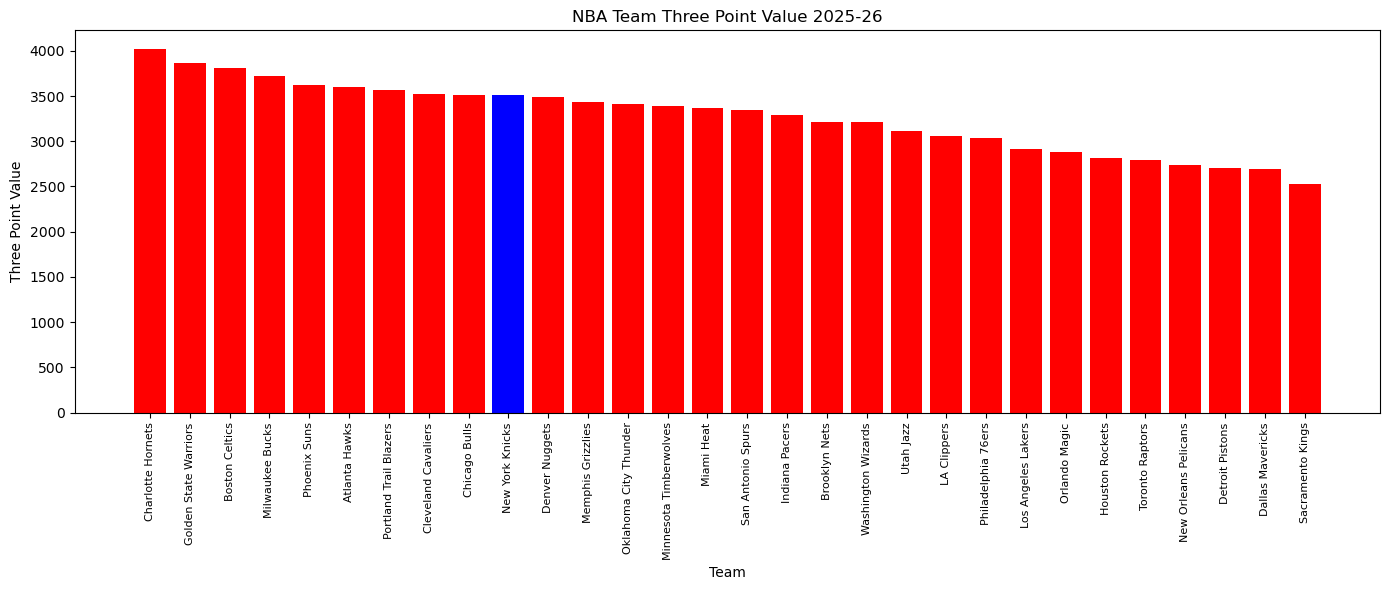

In [7]:
colors = ['blue' if team == 'New York Knicks' else 'red' for team in df_value_sorted['TEAM_NAME']]

plt.figure(figsize=(14, 6))
plt.bar(df_value_sorted['TEAM_NAME'], df_value_sorted['THREE_POINT_VALUE'], color=colors)
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Team')
plt.ylabel('Three Point Value')
plt.title('NBA Team Three Point Value 2025-26')
plt.tight_layout()
plt.show()

In this graph we can see the Knicks are 8th in the NBA in Three Point Value, with a value of 3505.827. This means they're about slightly above average in the amount they're benefitting from their three point shooting. Because they're 3pt percentage is so high, one could derive that the Knicks should start shooting more threes to derive more value. However, this strategy could lead to worse quality shots, which they would be less likely to make. The best logical option would be to adjust their offensive scheme to get more high quality open looks from three and less plays involving inside/isolation scoring. 